# Task 2: Exploratory Data Analysis (EDA) & Business Intelligence

### Internship Program
**ApexPlanet Software Pvt. Ltd.**

**Intern Name:** Harshi Salapu

**Task:** Exploratory Data Analysis & Business Intelligence

---

## Objective

To analyze the cleaned sales dataset, discover meaningful business insights using Exploratory Data Analysis (EDA), answer business questions using SQL, and design a static dashboard for decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("Cleaned_Sales_Dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Age_Group,Month,Quarter
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,Young Adult,February,1
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,Senior,October,4
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,Senior,May,2
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,Senior,December,4
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,Adult,November,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            1000 non-null   float64
 5   Gender         1000 non-null   object 
 6   City           1000 non-null   object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
 12  Age_Group      1000 non-null   object 
 13  Month          1000 non-null   object 
 14  Quarter        1000 non-null   int64  
dtypes: float64(3), int64(2), object(10)
memory usage: 117.3+ KB


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 15)


In [5]:

df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales', 'Age_Group', 'Month', 'Quarter'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Product,0
Category,0
Quantity,0


In [7]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales,Quarter
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.353000,5.435000,25486.783410,139399.439650,2.499000
std,13.683626,2.838632,14179.402361,114100.051546,1.131937
min,18.000000,1.000000,145.780000,437.340000,1.000000
25%,30.000000,3.000000,13895.722500,47066.632500,1.000000
50%,41.000000,5.000000,25398.740000,108594.025000,2.000000
75%,53.000000,8.000000,37512.382500,203722.882500,4.000000
max,65.000000,10.000000,49997.530000,493677.500000,4.000000


In [8]:
df.mean(numeric_only=True)

,0
Age,41.35300
Quantity,5.43500
Unit_Price,25486.78341
Total_Sales,139399.43965
Quarter,2.49900


In [9]:
df.median(numeric_only=True)

,0
Age,41.000
Quantity,5.000
Unit_Price,25398.740
Total_Sales,108594.025
Quarter,2.000


In [10]:
df.std(numeric_only=True)

,0
Age,13.683626
Quantity,2.838632
Unit_Price,14179.402361
Total_Sales,114100.051546
Quarter,1.131937


In [11]:
df["Category"].value_counts()

,count
Category,
Electronics,354
Education,178
Furniture,159
Fashion,156
Grocery,153


In [14]:
print(df.columns.tolist())


['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Total_Sales', 'Age_Group', 'Month', 'Quarter']


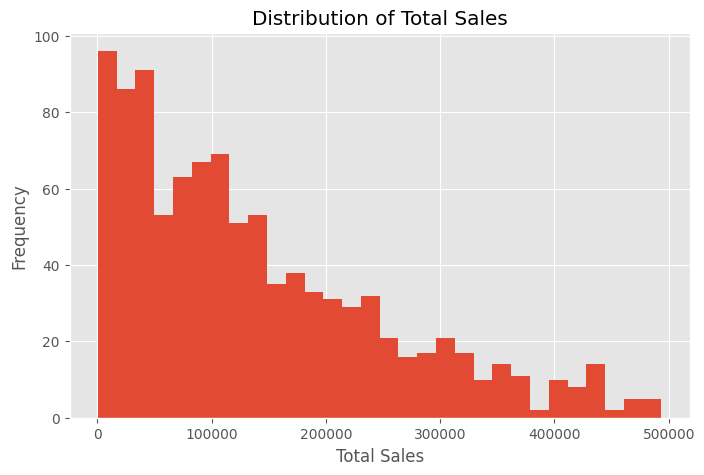

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["Total_Sales"], bins=30)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.show()

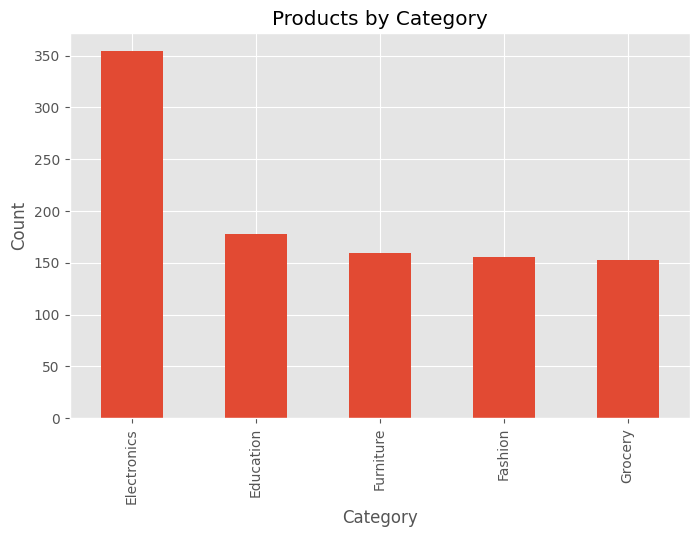

In [16]:
df["Category"].value_counts().plot(kind="bar", figsize=(8,5))

plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

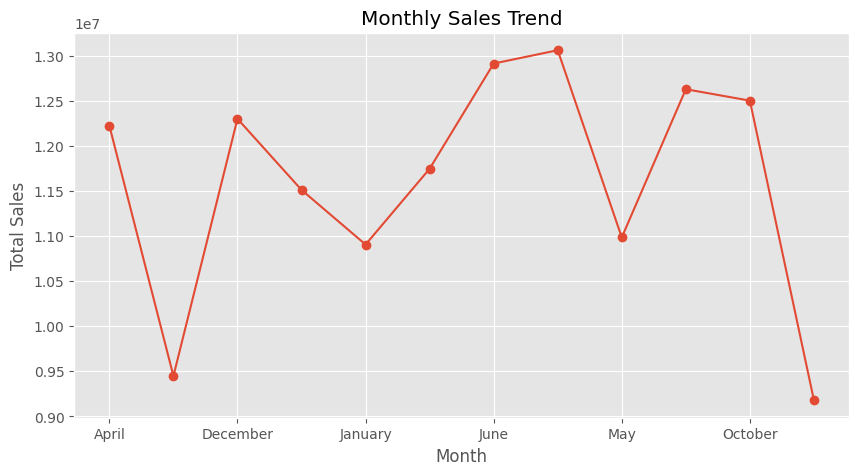

In [17]:
monthly_sales = df.groupby("Month")["Total_Sales"].sum()

monthly_sales.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

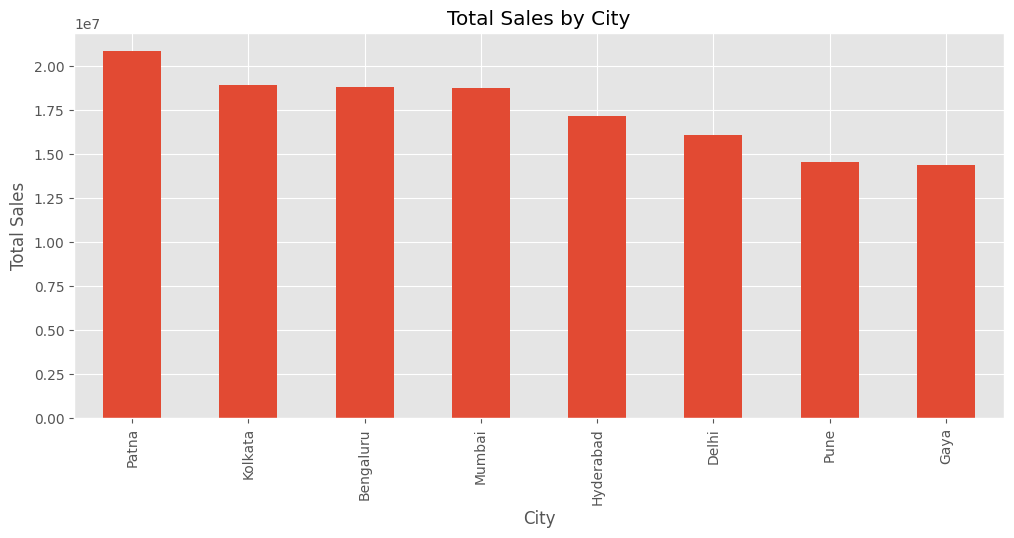

In [18]:
city_sales = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)

city_sales.plot(kind="bar", figsize=(12,5))

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.show()

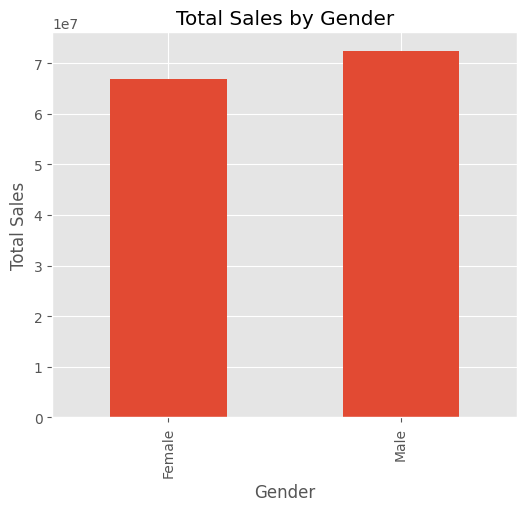

In [19]:
gender_sales = df.groupby("Gender")["Total_Sales"].sum()

gender_sales.plot(kind="bar", figsize=(6,5))

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.show()

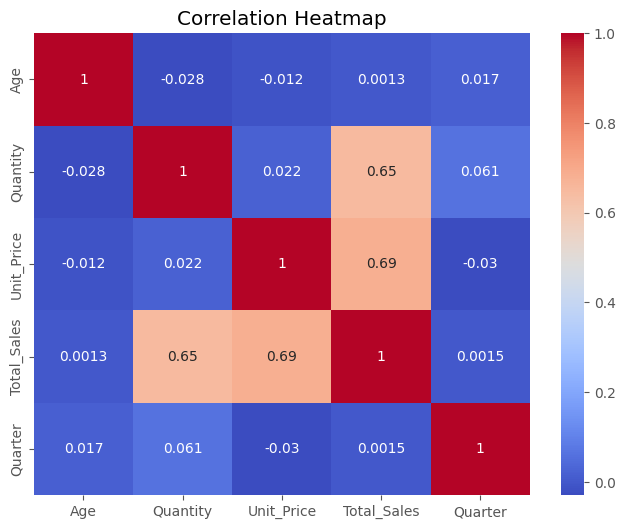

In [20]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

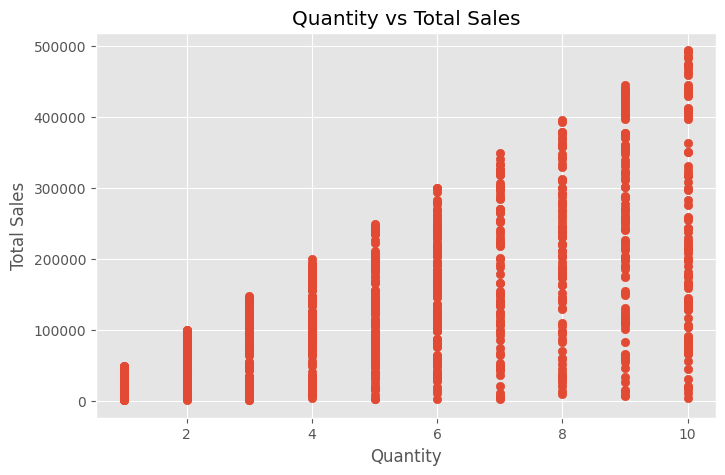

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(df["Quantity"], df["Total_Sales"])

plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.title("Quantity vs Total Sales")

plt.show()

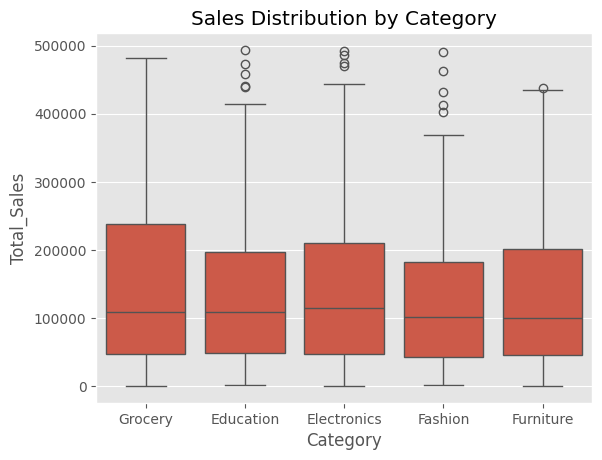

In [22]:
sns.boxplot(x="Category", y="Total_Sales", data=df)

plt.title("Sales Distribution by Category")

plt.show()

# Business Insights

## Key Findings

1. The sales distribution indicates that most transactions are of moderate value, with a few high-value purchases contributing significantly to total revenue.

2. Product categories show different levels of demand, helping identify the most popular categories.

3. Monthly sales analysis highlights seasonal trends that can assist in inventory and marketing planning.

4. Sales vary across cities, indicating stronger market performance in certain locations.

5. Gender-wise sales comparison provides insights into customer purchasing behavior.

6. The correlation analysis shows how numerical variables such as Quantity, Unit Price, Age, and Total Sales are related.

7. The box plot identifies the variation in sales across different categories and highlights any outliers.

# Conclusion

The Exploratory Data Analysis (EDA) provided valuable insights into customer purchasing patterns, product performance, and sales trends. Various visualizations and statistical analyses helped identify important business metrics and potential areas for improvement. These findings can support better business decisions related to inventory management, marketing strategies, and customer targeting.